# 02 — Análisis exploratorio

## Actividad física de ocio y síntomas depresivos

Este notebook describe el dataset, estudia sus distribuciones y muestra los primeros patrones entre actividad física y PHQ-9. No se realizan todavía pruebas de hipótesis.

## 1. Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Carga de datos

In [2]:
df = pd.read_csv(
    "../data/processed/nhanes_actividad_depresion_final.csv"
)

df.head()

,id,sesiones_moderadas_semana,duracion_moderada_sesion_min,actividad_moderada_ocio_min_semana,sesiones_vigorosas_semana,duracion_vigorosa_sesion_min,actividad_vigorosa_ocio_min_semana,sesiones_totales_semana,duracion_media_sesion_min,actividad_total_ocio_min_semana,actividad_equivalente_ocio_min_semana,nivel_actividad,perfil_actividad,alcanza_umbral_actividad,flag_actividad_extrema,phq_interes_placer,phq_animo_deprimido,phq_problemas_sueno,phq_fatiga_energia,phq_apetito,phq_autoestima_fracaso,phq_concentracion,phq_alteracion_psicomotora,phq_pensamientos_muerte_autolesion,phq9,nivel_sintomas_depresivos,sintomas_depresivos_relevantes,numero_sintomas_presentes,numero_sintomas_frecuentes
0,130379,4.0,45.0,180.0,3.00,45.0,135.00,7.00,45.00,315.00,450.00,Alto,Moderada + vigorosa,Sí,No,0,0,1,0,0,0,0,0,0,1,Mínimos,No,1,0
1,130380,1.0,20.0,20.0,0.00,0.0,0.00,1.00,20.00,20.00,20.00,Insuficiente,Solo moderada,No,No,0,0,1,1,0,0,0,0,0,2,Mínimos,No,2,0
2,130386,1.0,30.0,30.0,0.23,30.0,6.92,1.23,30.02,36.92,43.84,Insuficiente,Moderada + vigorosa,No,No,0,0,0,0,0,1,0,0,0,1,Mínimos,No,1,0
3,130387,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,Inactivo,Inactivo,No,No,0,0,0,0,0,0,0,0,0,0,Mínimos,No,0,0
4,130389,3.0,45.0,135.0,0.46,30.0,13.85,3.46,43.02,148.85,162.70,Recomendado,Moderada + vigorosa,Sí,No,0,0,0,0,0,0,0,0,0,0,Mínimos,No,0,0


## 3. Tamaño del dataset

In [3]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 5155
Columnas: 29


## 4. Información general

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5155 entries, 0 to 5154
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     5155 non-null   int64  
 1   sesiones_moderadas_semana              5155 non-null   float64
 2   duracion_moderada_sesion_min           5155 non-null   float64
 3   actividad_moderada_ocio_min_semana     5155 non-null   float64
 4   sesiones_vigorosas_semana              5155 non-null   float64
 5   duracion_vigorosa_sesion_min           5155 non-null   float64
 6   actividad_vigorosa_ocio_min_semana     5155 non-null   float64
 7   sesiones_totales_semana                5155 non-null   float64
 8   duracion_media_sesion_min              5155 non-null   float64
 9   actividad_total_ocio_min_semana        5155 non-null   float64
 10  actividad_equivalente_ocio_min_semana  5155 non-null   float64
 11  nive

## 5. Valores nulos y duplicados

In [5]:
print("Valores nulos:", df.isna().sum().sum())
print("IDs duplicados:", df["id"].duplicated().sum())
print("Filas duplicadas:", df.duplicated().sum())

Valores nulos: 0
IDs duplicados: 0
Filas duplicadas: 0


## 6. Estadísticos descriptivos

In [6]:
columnas_numericas = [
    "actividad_moderada_ocio_min_semana",
    "actividad_vigorosa_ocio_min_semana",
    "actividad_total_ocio_min_semana",
    "actividad_equivalente_ocio_min_semana",
    "sesiones_moderadas_semana",
    "sesiones_vigorosas_semana",
    "sesiones_totales_semana",
    "phq9",
    "numero_sintomas_presentes",
    "numero_sintomas_frecuentes"
]

df[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
actividad_moderada_ocio_min_semana,5155.0,222.487558,386.491882,0.0,27.69,120.00,240.0,5040.0
actividad_vigorosa_ocio_min_semana,5155.0,70.429779,239.076230,0.0,0.00,0.00,60.0,6720.0
actividad_total_ocio_min_semana,5155.0,292.917337,516.474933,0.0,30.00,150.00,360.0,7200.0
actividad_equivalente_ocio_min_semana,5155.0,363.347115,705.996902,0.0,30.00,180.00,420.0,13920.0
sesiones_moderadas_semana,5155.0,3.701286,5.585268,0.0,0.92,3.00,5.0,140.0
sesiones_vigorosas_semana,5155.0,1.197009,3.294584,0.0,0.00,0.00,2.0,70.0
sesiones_totales_semana,5155.0,4.898295,7.315195,0.0,1.00,3.23,7.0,143.0
phq9,5155.0,4.019593,4.664636,0.0,1.00,2.00,6.0,26.0
numero_sintomas_presentes,5155.0,2.729389,2.539158,0.0,1.00,2.00,5.0,9.0
numero_sintomas_frecuentes,5155.0,0.888458,1.636961,0.0,0.00,0.00,1.0,9.0


## 7. Nivel de actividad

In [7]:
orden_nivel = [
    "Inactivo",
    "Insuficiente",
    "Recomendado",
    "Alto"
]

nivel_actividad = (
    df["nivel_actividad"]
    .value_counts()
    .reindex(orden_nivel)
)

nivel_actividad

nivel_actividad
Inactivo         922
Insuficiente    1466
Recomendado      924
Alto            1843
Name: count, dtype: int64

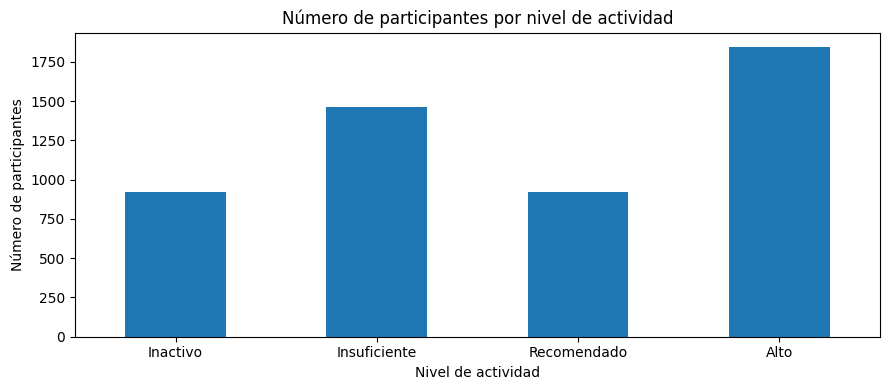

In [8]:
nivel_actividad.plot(
    kind="bar",
    figsize=(9, 4)
)

plt.title("Número de participantes por nivel de actividad")
plt.xlabel("Nivel de actividad")
plt.ylabel("Número de participantes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Perfil de actividad

In [9]:
orden_perfil = [
    "Inactivo",
    "Solo moderada",
    "Solo vigorosa",
    "Moderada + vigorosa"
]

perfil_actividad = (
    df["perfil_actividad"]
    .value_counts()
    .reindex(orden_perfil)
)

perfil_actividad

perfil_actividad
Inactivo                922
Solo moderada          1841
Solo vigorosa            60
Moderada + vigorosa    2332
Name: count, dtype: int64

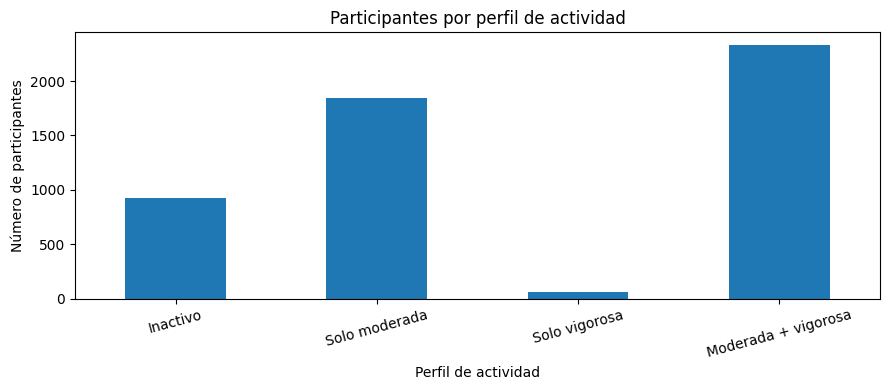

In [10]:
perfil_actividad.plot(
    kind="bar",
    figsize=(9, 4)
)

plt.title("Participantes por perfil de actividad")
plt.xlabel("Perfil de actividad")
plt.ylabel("Número de participantes")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 9. Distribución de actividad total

In [11]:
df["actividad_total_ocio_min_semana"].describe()

count    5155.000000
mean      292.917337
std       516.474933
min         0.000000
25%        30.000000
50%       150.000000
75%       360.000000
max      7200.000000
Name: actividad_total_ocio_min_semana, dtype: float64

P99: 2520.0 minutos por semana


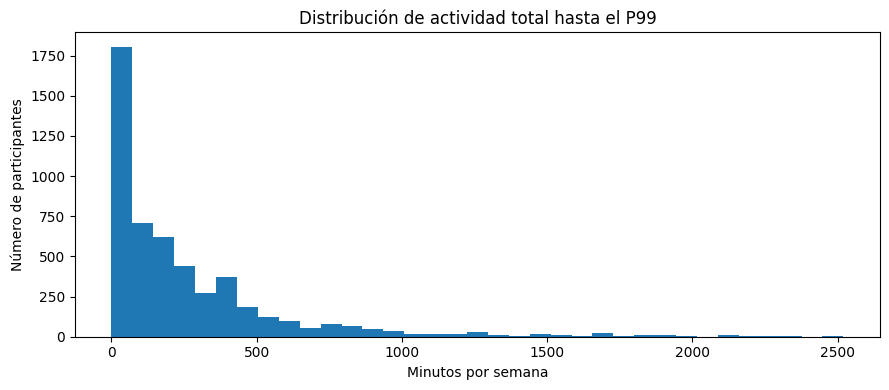

In [12]:
p99 = (
    df["actividad_total_ocio_min_semana"]
    .quantile(0.99)
)

actividad_hasta_p99 = df.loc[
    df["actividad_total_ocio_min_semana"] <= p99
]

print("P99:", round(p99, 2), "minutos por semana")

plt.figure(figsize=(9, 4))

plt.hist(
    actividad_hasta_p99["actividad_total_ocio_min_semana"],
    bins=35
)

plt.title("Distribución de actividad total hasta el P99")
plt.xlabel("Minutos por semana")
plt.ylabel("Número de participantes")
plt.tight_layout()
plt.show()

## 10. Actividad moderada y vigorosa

In [13]:
actividad_media = df[
    [
        "actividad_moderada_ocio_min_semana",
        "actividad_vigorosa_ocio_min_semana"
    ]
].mean()

actividad_media.index = [
    "Moderada",
    "Vigorosa"
]

actividad_media

Moderada    222.487558
Vigorosa     70.429779
dtype: float64

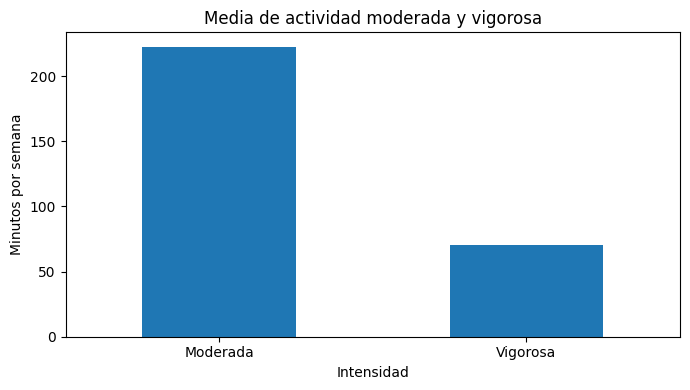

In [14]:
actividad_media.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Media de actividad moderada y vigorosa")
plt.xlabel("Intensidad")
plt.ylabel("Minutos por semana")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Distribución de PHQ-9

In [15]:
df["phq9"].describe()

count    5155.000000
mean        4.019593
std         4.664636
min         0.000000
25%         1.000000
50%         2.000000
75%         6.000000
max        26.000000
Name: phq9, dtype: float64

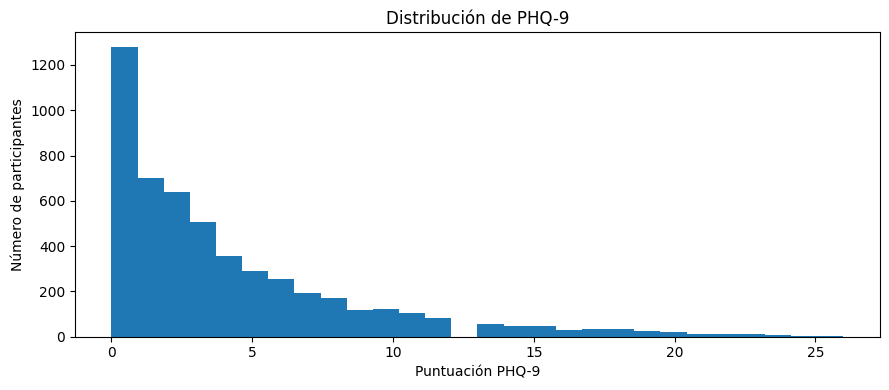

In [16]:
plt.figure(figsize=(9, 4))

plt.hist(
    df["phq9"],
    bins=28
)

plt.title("Distribución de PHQ-9")
plt.xlabel("Puntuación PHQ-9")
plt.ylabel("Número de participantes")
plt.tight_layout()
plt.show()

## 12. Nivel de síntomas depresivos

In [17]:
orden_sintomas = [
    "Mínimos",
    "Leves",
    "Moderados",
    "Moderadamente graves",
    "Graves"
]

nivel_sintomas = (
    df["nivel_sintomas_depresivos"]
    .value_counts()
    .reindex(orden_sintomas)
)

nivel_sintomas

nivel_sintomas_depresivos
Mínimos                 3482
Leves                   1025
Moderados                412
Moderadamente graves     169
Graves                    67
Name: count, dtype: int64

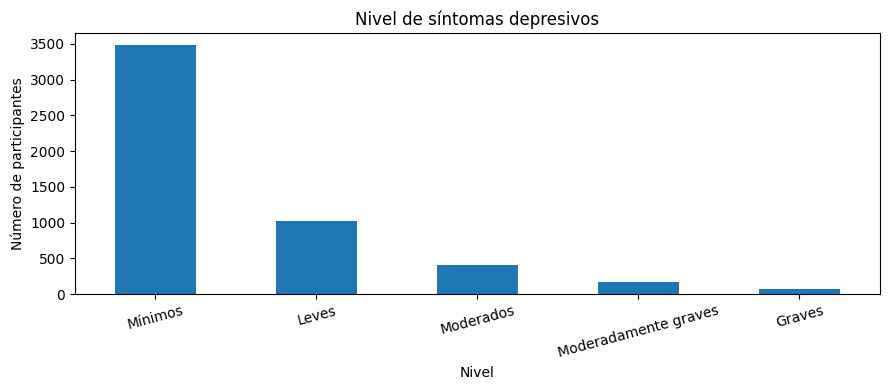

In [18]:
nivel_sintomas.plot(
    kind="bar",
    figsize=(9, 4)
)

plt.title("Nivel de síntomas depresivos")
plt.xlabel("Nivel")
plt.ylabel("Número de participantes")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 13. PHQ-9 igual o superior a 10

In [19]:
phq10 = (
    df["sintomas_depresivos_relevantes"]
    .value_counts()
    .reindex(["No", "Sí"])
)

phq10

sintomas_depresivos_relevantes
No    4507
Sí     648
Name: count, dtype: int64

In [20]:
porcentaje_phq10 = (
    phq10
    / len(df)
    * 100
).round(2)

porcentaje_phq10

sintomas_depresivos_relevantes
No    87.43
Sí    12.57
Name: count, dtype: float64

## 14. Síntomas individuales

In [21]:
nombres_sintomas = {
    "phq_interes_placer": "Interés / placer",
    "phq_animo_deprimido": "Ánimo deprimido",
    "phq_problemas_sueno": "Problemas de sueño",
    "phq_fatiga_energia": "Fatiga / energía",
    "phq_apetito": "Apetito",
    "phq_autoestima_fracaso": "Autoestima / fracaso",
    "phq_concentracion": "Concentración",
    "phq_alteracion_psicomotora": "Alteración psicomotora",
    "phq_pensamientos_muerte_autolesion": "Muerte / autolesión"
}

media_sintomas = (
    df[list(nombres_sintomas.keys())]
    .mean()
    .rename(index=nombres_sintomas)
    .sort_values(ascending=False)
)

media_sintomas.round(3)

Fatiga / energía          0.839
Problemas de sueño        0.772
Apetito                   0.481
Interés / placer          0.465
Ánimo deprimido           0.448
Autoestima / fracaso      0.388
Concentración             0.375
Alteración psicomotora    0.185
Muerte / autolesión       0.066
dtype: float64

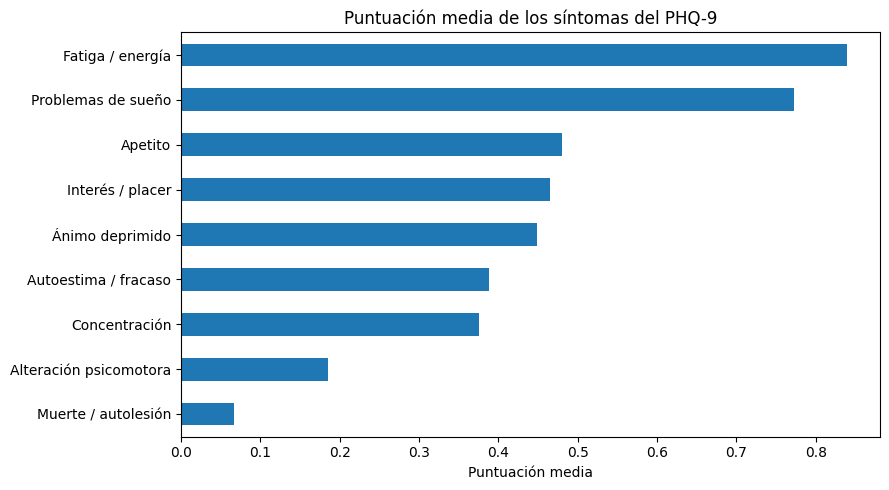

In [22]:
media_sintomas.sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Puntuación media de los síntomas del PHQ-9")
plt.xlabel("Puntuación media")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 15. PHQ-9 por nivel de actividad

In [23]:
resumen_nivel = (
    df.groupby("nivel_actividad")
    .agg(
        participantes=("id", "count"),
        phq_media=("phq9", "mean"),
        phq_mediana=("phq9", "median")
    )
    .reindex(orden_nivel)
)

resumen_nivel.round(2)

,participantes,phq_media,phq_mediana
nivel_actividad,,,
Inactivo,922,5.31,3.0
Insuficiente,1466,4.37,3.0
Recomendado,924,3.42,2.0
Alto,1843,3.40,2.0


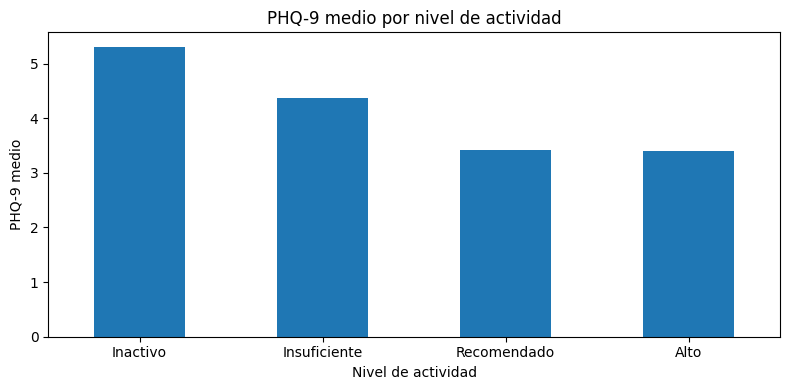

In [24]:
resumen_nivel["phq_media"].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("PHQ-9 medio por nivel de actividad")
plt.xlabel("Nivel de actividad")
plt.ylabel("PHQ-9 medio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. PHQ-9 ≥ 10 por nivel de actividad

In [25]:
phq10_por_nivel = (
    df.assign(
        phq10=df["sintomas_depresivos_relevantes"] == "Sí"
    )
    .groupby("nivel_actividad")["phq10"]
    .mean()
    .reindex(orden_nivel)
    * 100
)

phq10_por_nivel.round(2)

nivel_actividad
Inactivo        20.50
Insuficiente    13.57
Recomendado      9.09
Alto             9.55
Name: phq10, dtype: float64

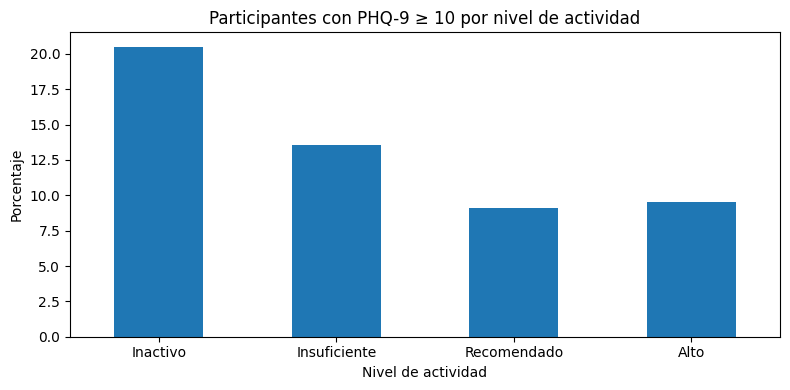

In [26]:
phq10_por_nivel.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Participantes con PHQ-9 ≥ 10 por nivel de actividad")
plt.xlabel("Nivel de actividad")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 17. Boxplot de PHQ-9 por nivel de actividad

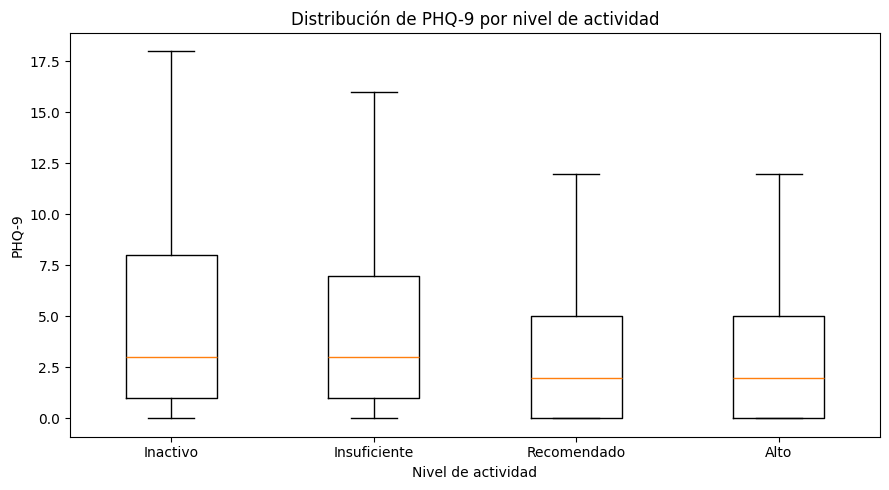

In [27]:
datos_boxplot = [
    df.loc[
        df["nivel_actividad"] == nivel,
        "phq9"
    ]
    for nivel in orden_nivel
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    datos_boxplot,
    tick_labels=orden_nivel,
    showfliers=False
)

plt.title("Distribución de PHQ-9 por nivel de actividad")
plt.xlabel("Nivel de actividad")
plt.ylabel("PHQ-9")
plt.tight_layout()
plt.show()

## 18. Correlaciones exploratorias

In [28]:
variables_actividad = [
    "actividad_moderada_ocio_min_semana",
    "actividad_vigorosa_ocio_min_semana",
    "actividad_total_ocio_min_semana",
    "actividad_equivalente_ocio_min_semana",
    "sesiones_totales_semana"
]

correlaciones = (
    df[variables_actividad + ["phq9"]]
    .corr(method="spearman")["phq9"]
    .drop("phq9")
    .sort_values()
)

correlaciones.round(3)

sesiones_totales_semana                 -0.153
actividad_total_ocio_min_semana         -0.149
actividad_equivalente_ocio_min_semana   -0.148
actividad_moderada_ocio_min_semana      -0.145
actividad_vigorosa_ocio_min_semana      -0.092
Name: phq9, dtype: float64

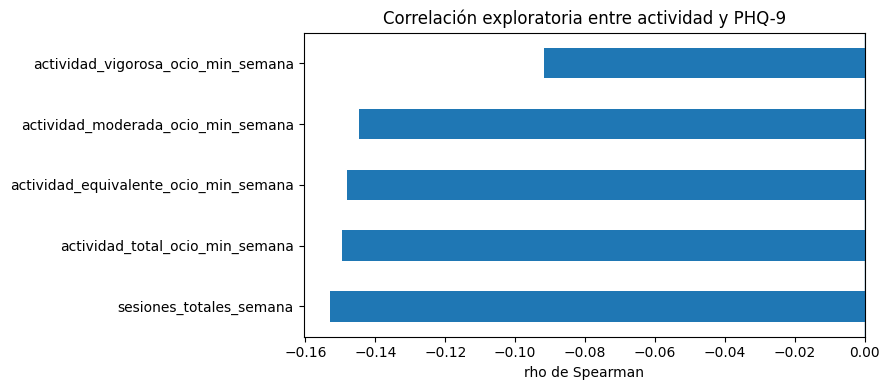

In [29]:
correlaciones.plot(
    kind="barh",
    figsize=(9, 4)
)

plt.axvline(
    0,
    linewidth=1
)

plt.title("Correlación exploratoria entre actividad y PHQ-9")
plt.xlabel("rho de Spearman")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 19. Valores extremos

In [30]:
df["flag_actividad_extrema"].value_counts()

flag_actividad_extrema
No    5107
Sí      48
Name: count, dtype: int64

## 20. Conclusiones exploratorias

- El dataset final está completo y no contiene duplicados.
- La actividad física presenta una distribución asimétrica y algunos valores muy altos.
- La mayoría de participantes presenta síntomas depresivos mínimos o leves.
- Los grupos con menor actividad muestran descriptivamente un PHQ-9 más alto.
- Las correlaciones entre actividad y PHQ-9 son negativas, pero de magnitud débil.
- Estos patrones deben contrastarse mediante pruebas inferenciales en el siguiente notebook.